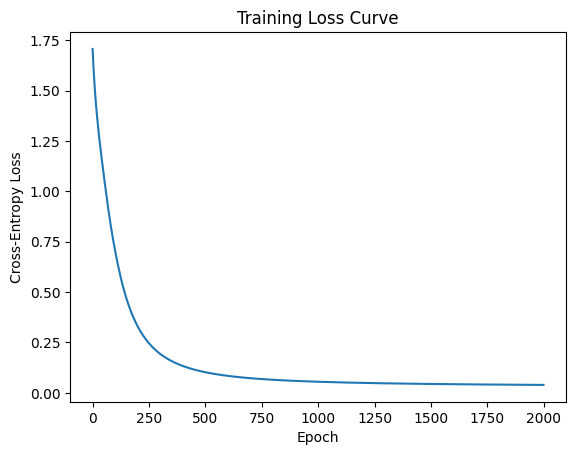


Test Accuracy: 0.9893333333333333

Precision per class: [1.         0.94936709 1.         1.         1.        ]
Recall per class: [1.         1.         1.         0.97333333 0.97333333]
F1-score per class: [1.         0.97402597 1.         0.98648649 0.98648649]

Macro F1: 0.9893997893997893


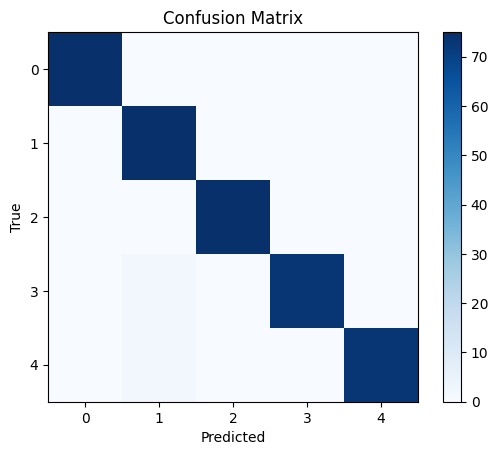

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split

np.random.seed(0)


N = 1500
features = 3
classes = 5

# Create 5 cluster centers
centers = np.array([
    [2, 2, 0],
    [-2, 2, 0],
    [2, -2, 0],
    [-2, -2, 0],
    [0, 0, 3]
])

X = np.zeros((N, features))
Y = np.zeros((N, 1), dtype=int)


for c in range(classes):
    idx = slice(c * (N // classes), (c + 1) * (N // classes))
    X[idx] = centers[c] + 0.8 * np.random.randn(N // classes, features)
    Y[idx] = c




def one_hot(y, num_classes):
    arr = np.zeros((len(y), num_classes))
    arr[np.arange(len(y)), y.flatten()] = 1
    return arr

Y_oh = one_hot(Y, classes)


X_train, X_test, Y_train, Y_test, Y_train_oh, Y_test_oh = train_test_split(
    X, Y, Y_oh, test_size=0.25, random_state=42, stratify=Y
)

class NeuralNetwork(object):
    def __init__(self, in_dim=3, h1=32, h2=32, h3=32, out_dim=5, lr=0.01):
        self.lr = lr

        self.W1 = np.random.randn(in_dim, h1) / np.sqrt(in_dim)
        self.W2 = np.random.randn(h1, h2) / np.sqrt(h1)
        self.W3 = np.random.randn(h2, h3) / np.sqrt(h2)
        self.W4 = np.random.randn(h3, out_dim) / np.sqrt(h3)

    def relu(self, x):
        return np.maximum(0, x)

    def relu_deriv(self, x):
        return (x > 0).astype(float)

    def softmax(self, z):

        exp = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp / np.sum(exp, axis=1, keepdims=True)


    def feedForward(self, X):
        self.z1 = X @ self.W1
        self.a1 = self.relu(self.z1)

        self.z2 = self.a1 @ self.W2
        self.a2 = self.relu(self.z2)

        self.z3 = self.a2 @ self.W3
        self.a3 = self.relu(self.z3)

        self.z4 = self.a3 @ self.W4
        self.out = self.softmax(self.z4)

        return self.out


    def backPropagation(self, X, Y):

        dZ4 = (self.out - Y) / len(X)

        dW4 = self.a3.T @ dZ4
        dZ3 = (dZ4 @ self.W4.T) * self.relu_deriv(self.z3)

        dW3 = self.a2.T @ dZ3
        dZ2 = (dZ3 @ self.W3.T) * self.relu_deriv(self.z2)

        dW2 = self.a1.T @ dZ2
        dZ1 = (dZ2 @ self.W2.T) * self.relu_deriv(self.z1)

        dW1 = X.T @ dZ1


        self.W4 -= self.lr * dW4
        self.W3 -= self.lr * dW3
        self.W2 -= self.lr * dW2
        self.W1 -= self.lr * dW1

    def train(self, X, Y):
        out = self.feedForward(X)
        self.backPropagation(X, Y)
        return out



NN = NeuralNetwork()

epochs = 2000
losses = []

for epoch in range(epochs):
    out = NN.train(X_train, Y_train_oh)


    loss = -np.mean(np.sum(Y_train_oh * np.log(out + 1e-8), axis=1))
    losses.append(loss)


plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.show()


pred_test = NN.feedForward(X_test)
pred_labels = np.argmax(pred_test, axis=1)
true_labels = Y_test.flatten()


accuracy = np.mean(pred_labels == true_labels)
print("\nTest Accuracy:", accuracy)

prec, rec, f1, _ = precision_recall_fscore_support(
    true_labels, pred_labels, average=None, labels=[0,1,2,3,4]
)

print("\nPrecision per class:", prec)
print("Recall per class:", rec)
print("F1-score per class:", f1)
print("\nMacro F1:", np.mean(f1))


cm = confusion_matrix(true_labels, pred_labels)

plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
